[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Daniel-534/IntroduccionAstronomiaPractica/blob/main/ProyectoEratostenes/ProyectoEratostenes.ipynb)

# Midiendo el Radio Terrestre: Método de Eratóstenes

## Universidad de Antioquia — Introducción a la Astronomía Práctica

| Parámetro | Detalle |
|---|---|
| **Lugar de observación** | Plazoleta central, Universidad de Antioquia, Medellín, Colombia |
| **Coordenadas** | 6.2666°N, 75.5694°O |
| **Fechas** | 19 y 20 de marzo de 2026 |
| **Zona horaria** | UTC−5 (hora Colombia) |
| **Autores** | Daniel Soto Villada, Jean Lucca Buritica Cuervo, Camilo Higuita |

---

En el siglo III a.C., **Eratóstenes de Cirene** (c. 276–194 a.C.) midió la circunferencia de la Tierra
con una elegancia que aún sorprende. Sabía que en el solsticio de verano el Sol iluminaba el fondo de
un pozo en Siena (hoy Asuán), indicando que estaba en el cenit, mientras que en Alejandría proyectaba
sombra. Midiendo ese ángulo y conociendo la distancia entre las dos ciudades, estimó la circunferencia
terrestre con notable precisión (Britannica, 2024).

Nosotros reproducimos ese experimento con un **gnomon** (vara vertical) en la plazoleta de la
Universidad de Antioquia. Realizamos dos sesiones de medición: el **19 de marzo** (un día antes del
equinoccio vernal) y el **20 de marzo de 2026** (equinoccio vernal), fecha especial en la que la
declinación solar es cero y la distancia cenital al mediodía solar es exactamente igual a la latitud
geográfica del observador.


In [2]:
# ════════════════════════════════════════════════════════
# Importaciones y configuración
# ════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Arc
from scipy.optimize import curve_fit
from datetime import datetime
import os, warnings

warnings.filterwarnings('ignore')

# Carpeta de figuras
IMG_DIR = 'img'
os.makedirs(IMG_DIR, exist_ok=True)

# Estilo global de matplotlib
plt.rcParams.update({
    'figure.dpi': 200,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'lines.linewidth': 2,
    'grid.alpha': 0.35,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
})

print("✓ Entorno configurado.")
print(f"✓ Figuras → '{os.path.abspath(IMG_DIR)}'")


✓ Entorno configurado.
✓ Figuras → '/Users/danielvillada/Documents/IntroduccionAstronomiaPractica/ProyectoEratostenes/img'


---
## 1. Fundamento Teórico

### 1.1 Geometría del gnomon

Un **gnomon** es una vara vertical de longitud $L$ conocida. La longitud $s$ de su sombra sobre el plano
horizontal depende de la posición del Sol. Las fórmulas trigonométricas son (Portilla Barbosa, 2009):

$$h = \arctan\!\left(\frac{L}{s}\right) \qquad \text{(ángulo de elevación solar)}$$

$$z = 90° - h = \arctan\!\left(\frac{s}{L}\right) \qquad \text{(distancia cenital)}$$

La sombra es **mínima** cuando el Sol cruza el meridiano del observador: el **mediodía solar**.

### 1.2 Equinoccio y latitud geográfica

En el equinoccio, la declinación solar $\delta = 0°$. La altura al mediodía en latitud $\varphi$ es (Portilla Barbosa, 2009):

$$h_{\text{noon}} = 90° - \varphi + \delta = 90° - \varphi$$

Por lo tanto, la distancia cenital al mediodía es exactamente la latitud:

$$\boxed{z_{\text{equinoccio}} = \varphi}$$

Fuera del equinoccio (día 19, $\delta \neq 0$):

$$z = \varphi - \delta \quad \Rightarrow \quad \varphi = z + \delta$$

### 1.3 Método de Eratóstenes

Tomando el ecuador como segundo punto de referencia ($z_{\text{ecuador}} = 0°$), la diferencia angular
es $\Delta z = \varphi$. Dada la distancia meridional $d$ entre el ecuador y la ubicación de observación
(Portilla Barbosa, 2009; Britannica, 2024):

$$C = \frac{360°}{\varphi} \cdot d \qquad \Longrightarrow \qquad \boxed{R = \frac{d}{\varphi_{\text{rad}}}}$$

### 1.4 Propagación de incertidumbres

Aplicando diferenciación total sobre $z = \arctan(s/L)$ según Baird (1991, secciones 2-7 y 2-9):

$$\delta z = \left|\frac{\partial z}{\partial s}\right|\delta s + \left|\frac{\partial z}{\partial L}\right|\delta L = \frac{L\,\delta s + s\,\delta L}{L^2 + s^2} \qquad [\text{rad}]$$

Para el radio terrestre (usando la regla del producto/cociente de Baird):

$$\frac{\delta R}{R} = \frac{\delta d}{d} + \frac{\delta z}{z}$$


In [3]:
# ════════════════════════════════════════════════════════
# Parámetros de los gnomons y del lugar
# ════════════════════════════════════════════════════════

# Día 19 de marzo 2026
L19  = 102.7   # longitud del gnomon (cm)
dL19 = 0.1     # incertidumbre en L19 (cm)
ds19 = 0.4     # incertidumbre en longitud de sombra (cm)

# Día 20 de marzo 2026 (equinoccio)
L20  = 102.0   # longitud del gnomon (cm)
dL20 = 0.1     # incertidumbre en L20 (cm)
ds20 = 0.3     # incertidumbre en longitud de sombra (cm)

# Coordenadas del lugar (Google Maps)
lat_real = 6.266635    # °N
lon_obs  = -75.569436  # °O

print("━"*55)
print(f"  Día 19 → gnomon: ({L19} ± {dL19}) cm  |  δs = ±{ds19} cm")
print(f"  Día 20 → gnomon: ({L20} ± {dL20}) cm  |  δs = ±{ds20} cm")
print(f"  Latitud real del lugar: {lat_real}°N  (Google Maps)")
print("━"*55)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Día 19 → gnomon: (102.7 ± 0.1) cm  |  δs = ±0.4 cm
  Día 20 → gnomon: (102.0 ± 0.1) cm  |  δs = ±0.3 cm
  Latitud real del lugar: 6.266635°N  (Google Maps)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


In [4]:
# ════════════════════════════════════════════════════════
# Carga de datos experimentales
# (leídos desde Datos20260319.dat y Datos20260320.dat)
# ════════════════════════════════════════════════════════

def parse_dat(records, date_str):
    'Convierte [(hora, sombra), ...] a DataFrame con tiempo relativo.'
    rows = []
    for hora, s in records:
        dt = datetime.strptime(f"{date_str} {hora}", "%Y-%m-%d %H:%M:%S")
        noon = dt.replace(hour=12, minute=0, second=0, microsecond=0)
        t_rel = (dt - noon).total_seconds() / 60.0
        rows.append({"Hora": hora, "datetime": dt, "t_min": t_rel, "sombra_cm": s})
    df = pd.DataFrame(rows).sort_values("t_min").reset_index(drop=True)
    return df

# Los datos se almacenan como listas Python con el prefijo 'raw' porque
# contienen los valores exactamente como fueron registrados en campo
# (datos "crudos", sin procesamiento previo). Aunque la fuente original
# son los archivos Datos20260319.dat y Datos20260320.dat, se incorporan
# aquí directamente para garantizar la portabilidad del notebook y evitar
# dependencias de rutas externas que podrían variar entre entornos.

# Datos del 19 de marzo
raw19 = [
    ("11:56:30", 14.8), ("11:58:40", 16.0), ("12:00:00", 15.0),
    ("12:07:27", 16.9), ("12:09:29", 16.3), ("12:12:12", 13.7),
    ("12:14:40", 15.4),
]
df19 = parse_dat(raw19, "2026-03-19")

# Datos del 20 de marzo
raw20 = [
    ("11:57:23", 13.0), ("12:10:51", 11.3),
    ("12:12:08", 11.2), ("12:14:37", 11.3),
]
df20 = parse_dat(raw20, "2026-03-20")

print("═"*50)
print("  DATOS — 19 de marzo de 2026")
print("═"*50)
# La columna 't desde 12:00 (min)' representa el tiempo de cada medición
# en minutos respecto al mediodía civil (12:00:00 h). Se usa como variable
# independiente del ajuste parabólico s(t): el mínimo de la sombra ocurre
# cerca de las 12:00 h, por lo que t₀ ≈ 0 y los parámetros del ajuste
# resultan fácilmente interpretables.
disp19 = df19[["Hora", "t_min", "sombra_cm"]].copy()
disp19.columns = ["Hora", "t desde 12:00 (min)", "Sombra (cm)"]
disp19["t desde 12:00 (min)"] = disp19["t desde 12:00 (min)"].round(2)
print(disp19.to_string(index=False))
idx19 = df19["sombra_cm"].idxmin()
print(f"\n  ▶ Mínimo observado: {df19.loc[idx19,'sombra_cm']} cm  a las {df19.loc[idx19,'Hora']}")

print("\n" + "═"*50)
print("  DATOS — 20 de marzo de 2026  (EQUINOCCIO)")
print("═"*50)
disp20 = df20[["Hora", "t_min", "sombra_cm"]].copy()
disp20.columns = ["Hora", "t desde 12:00 (min)", "Sombra (cm)"]
disp20["t desde 12:00 (min)"] = disp20["t desde 12:00 (min)"].round(2)
print(disp20.to_string(index=False))
idx20 = df20["sombra_cm"].idxmin()
print(f"\n  ▶ Mínimo observado: {df20.loc[idx20,'sombra_cm']} cm  a las {df20.loc[idx20,'Hora']}")


══════════════════════════════════════════════════
  DATOS — 19 de marzo de 2026
══════════════════════════════════════════════════
    Hora  t desde 12:00 (min)  Sombra (cm)
11:56:30                -3.50         14.8
11:58:40                -1.33         16.0
12:00:00                 0.00         15.0
12:07:27                 7.45         16.9
12:09:29                 9.48         16.3
12:12:12                12.20         13.7
12:14:40                14.67         15.4

  ▶ Mínimo observado: 13.7 cm  a las 12:12:12

══════════════════════════════════════════════════
  DATOS — 20 de marzo de 2026  (EQUINOCCIO)
══════════════════════════════════════════════════
    Hora  t desde 12:00 (min)  Sombra (cm)
11:57:23                -2.62         13.0
12:10:51                10.85         11.3
12:12:08                12.13         11.2
12:14:37                14.62         11.3

  ▶ Mínimo observado: 11.2 cm  a las 12:12:08


---
## 2. Análisis Estadístico: Ajuste Parabólico

### 2.1 Justificación

La longitud de la sombra varía casi cuadráticamente con el tiempo alrededor del mediodía solar.
Esta aproximación se justifica por el movimiento armónico del Sol en torno al meridiano:
al desarrollar en serie de Taylor la función $s(t) = L\tan[z(t)]$ alrededor del instante
del mediodía solar $t_0$, la derivada de primer orden se anula por simetría y el término
dominante es cuadrático (Portilla Barbosa, 2009). Ajustar la parábola

$$s(t) = a\,(t - t_0)^2 + s_{\min}$$

permite:

1. **Estimar el mediodía solar** ($t_0$) por interpolación, evitando depender del único punto mínimo observado.
2. **Obtener la sombra mínima real** ($s_{\min}$) con mayor precisión estadística.
3. **Cuantificar la calidad del ajuste** con los residuos.

> **Nota sobre el día 19:** La mayor dispersión debida a la dificultad de verticalidad y al paso de nubes
> hace que el ajuste sea menos preciso que el del día 20. Reportamos ambos resultados con sus incertidumbres.


In [5]:
# ════════════════════════════════════════════════════════
# Ajuste parabólico: s(t) = a*(t - t0)^2 + s_min
# ════════════════════════════════════════════════════════

def parabola(t, a, t0, s_min):
    return a * (t - t0)**2 + s_min

def fit_parabola(df):
    t = df["t_min"].values
    s = df["sombra_cm"].values
    i_min = np.argmin(s)
    p0 = [0.05, t[i_min], s[i_min]]
    popt, pcov = curve_fit(parabola, t, s, p0=p0, maxfev=20000)
    perr = np.sqrt(np.diag(pcov))
    return popt, perr

def fmt_time(t_rel_min):
    'Convierte minutos desde 12:00 a string HH:MM:SS.'
    total_sec = 12*3600 + int(round(t_rel_min * 60))
    h = total_sec // 3600
    m = (total_sec % 3600) // 60
    s = total_sec % 60
    return f"{h:02d}:{m:02d}:{s:02d}"

popt19, perr19 = fit_parabola(df19)
popt20, perr20 = fit_parabola(df20)

a19, t0_19, smin19_fit = popt19
a20, t0_20, smin20_fit = popt20

print("═"*60)
print("  AJUSTE PARABÓLICO — 19 de marzo")
print("═"*60)
print(f"  a       = {a19:.4f} ± {perr19[0]:.4f}  cm/min²")
print(f"  t₀      = {t0_19:+.2f} ± {perr19[1]:.2f}  min  →  {fmt_time(t0_19)} (mediodía solar)")
print(f"  s_min   = {smin19_fit:.3f} ± {perr19[2]:.3f}  cm")

# Control de calidad: si el smin del ajuste es mayor que el mínimo observado,
# el ajuste es de baja calidad para ese parámetro
s19_obs_min = df19["sombra_cm"].min()
fit19_ok = smin19_fit < s19_obs_min + ds19   # within measurement uncertainty
if not fit19_ok:
    print(f"\n  ⚠️  ADVERTENCIA: s_min del ajuste ({smin19_fit:.2f} cm) > mínimo observado ({s19_obs_min:.1f} cm).")
    print(f"     Los datos del día 19 son demasiado dispersos para que el ajuste")
    print(f"     interpole correctamente s_min. Para los cálculos físicos se usará")
    print(f"     el mínimo observado directamente: s₁₉ = {s19_obs_min} cm")
    print(f"     (el t₀ del ajuste sigue siendo informativo para el mediodía solar).")

print("\n" + "═"*60)
print("  AJUSTE PARABÓLICO — 20 de marzo (equinoccio)")
print("═"*60)
print(f"  a       = {a20:.4f} ± {perr20[0]:.4f}  cm/min²")
print(f"  t₀      = {t0_20:+.2f} ± {perr20[1]:.2f}  min  →  {fmt_time(t0_20)} (mediodía solar)")
print(f"  s_min   = {smin20_fit:.3f} ± {perr20[2]:.3f}  cm")

# Control de calidad día 20
s20_obs_min = df20["sombra_cm"].min()
fit20_ok = smin20_fit < s20_obs_min + ds20
if fit20_ok:
    print(f"\n  ✓ Ajuste del día 20 consistente: s_min_fit ≈ s_min_obs ({s20_obs_min:.1f} cm).")


════════════════════════════════════════════════════════════
  AJUSTE PARABÓLICO — 19 de marzo
════════════════════════════════════════════════════════════
  a       = -0.0185 ± 0.0149  cm/min²
  t₀      = +5.22 ± 1.71  min  →  12:05:13 (mediodía solar)
  s_min   = 16.255 ± 0.775  cm

  ⚠️  ADVERTENCIA: s_min del ajuste (16.25 cm) > mínimo observado (13.7 cm).
     Los datos del día 19 son demasiado dispersos para que el ajuste
     interpole correctamente s_min. Para los cálculos físicos se usará
     el mínimo observado directamente: s₁₉ = 13.7 cm
     (el t₀ del ajuste sigue siendo informativo para el mediodía solar).

════════════════════════════════════════════════════════════
  AJUSTE PARABÓLICO — 20 de marzo (equinoccio)
════════════════════════════════════════════════════════════
  a       = 0.0078 ± 0.0015  cm/min²
  t₀      = +12.38 ± 1.35  min  →  12:12:23 (mediodía solar)
  s_min   = 11.247 ± 0.036  cm

  ✓ Ajuste del día 20 consistente: s_min_fit ≈ s_min_obs (11.2 cm).


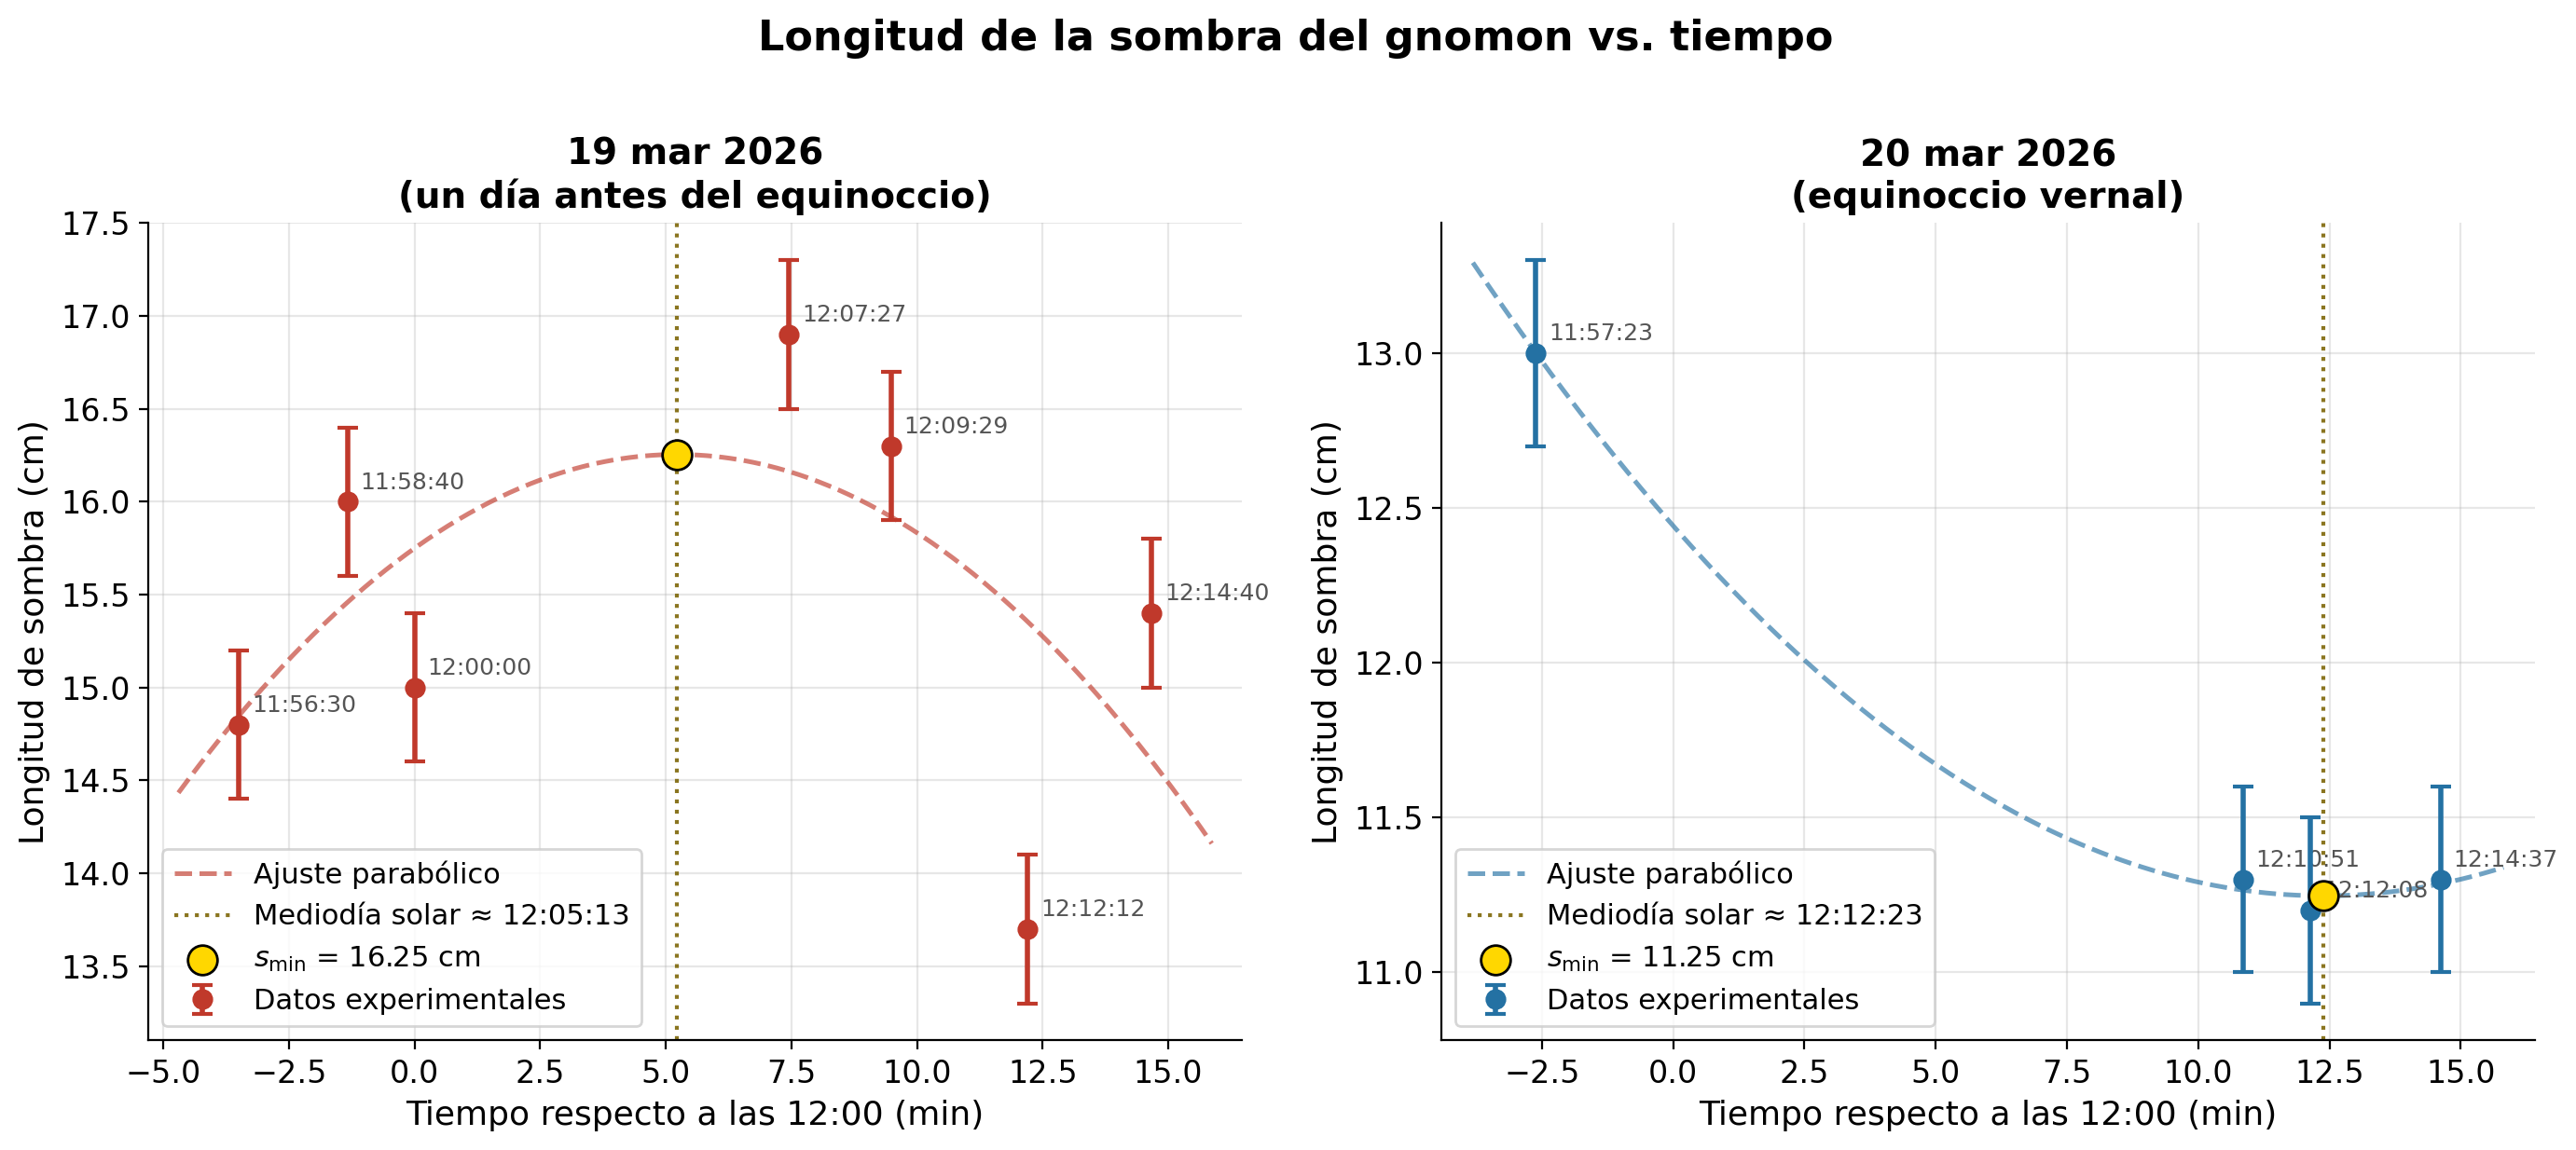

✓ fig1_sombra_vs_tiempo.png guardada.


In [6]:
# ════════════════════════════════════════════════════════
# FIGURA 1: Longitud de sombra vs. tiempo (ambos días)
# ════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

configs = [
    (axes[0], df19, popt19, perr19, ds19, "#C0392B",
     "19 mar 2026\n(un día antes del equinoccio)"),
    (axes[1], df20, popt20, perr20, ds20, "#2471A3",
     "20 mar 2026\n(equinoccio vernal)"),
]

for ax, df, popt, perr, ds, color, title in configs:
    t_fine = np.linspace(df["t_min"].min() - 1.2, df["t_min"].max() + 1.2, 400)
    s_fine = parabola(t_fine, *popt)

    # Datos con barras de error
    ax.errorbar(df["t_min"], df["sombra_cm"],
                yerr=ds, fmt='o', color=color, capsize=4, capthick=1.5,
                markersize=7, zorder=5, label="Datos experimentales")

    # Ajuste parabólico
    ax.plot(t_fine, s_fine, '--', color=color, alpha=0.65, lw=1.8,
            label="Ajuste parabólico")

    # Línea del mediodía solar
    ax.axvline(popt[1], color='#7D6608', linestyle=':', lw=1.5, alpha=0.9,
               label=f"Mediodía solar ≈ {fmt_time(popt[1])}")

    # Punto mínimo del ajuste
    ax.scatter([popt[1]], [popt[2]], color='gold', edgecolors='black',
               s=130, zorder=10, label=f"$s_{{\\min}}$ = {popt[2]:.2f} cm")

    # Etiquetas de hora en cada punto
    for _, row in df.iterrows():
        ax.annotate(row["Hora"], (row["t_min"], row["sombra_cm"]),
                    textcoords="offset points", xytext=(5, 5),
                    fontsize=9, color='#555555')

    ax.set_xlabel("Tiempo respecto a las 12:00 (min)", fontsize=13)
    ax.set_ylabel("Longitud de sombra (cm)", fontsize=13)
    ax.set_title(title, fontweight='bold', fontsize=14)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(df["t_min"].min() - 1.8, df["t_min"].max() + 1.8)

fig.suptitle("Longitud de la sombra del gnomon vs. tiempo",
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/fig1_sombra_vs_tiempo.png", bbox_inches='tight', dpi=200)
plt.show()
print("✓ fig1_sombra_vs_tiempo.png guardada.")


### 2.2 Interpretación del análisis estadístico

| Parámetro | 19 de marzo | 20 de marzo (equinoccio) |
|---|---|---|
| N° de medidas | 7 | 4 |
| Condiciones | Cielo despejado; gnomon sin soporte rígido | Muchas nubes; gnomon con soporte estable |
| Sombra mínima observada | 13.7 cm (12:12:12) | 11.2 cm (12:12:08) |

**Día 20:** El ajuste es satisfactorio. La sombra mínima del ajuste (~11.25 cm) coincide con
el mínimo observado (11.2 cm). Se usa el valor ajustado para el cálculo del radio.

**Día 19 — limitación del ajuste:** Los datos del día 19 no siguen un patrón parabólico claro.
Los valores a las 12:07 y 12:09 (16.9 y 16.3 cm) son mayores que los valores de 11:56–12:00
(14.8–16 cm), y el mínimo de 13.7 cm aparece al final del período de medición. Este comportamiento
se debe principalmente a la dificultad de mantener el gnomon perfectamente vertical y al grosor del
mismo, que introduce errores irregulares. Como resultado, **el ajuste parabólico no puede interpolar
correctamente la sombra mínima del día 19** (smin_fit > smin_obs). Para los cálculos físicos del
día 19 se usa el mínimo observado directamente (13.7 cm). El parámetro $t_0$ del ajuste parabólico
sí es informativo para estimar el momento del mediodía solar.

- Ambos ajustes ubican el mediodía solar alrededor de las **12:12**, consistente con la longitud
  geográfica de Medellín (−75.57°), que añade ~ 2.3 min respecto al meridiano de la zona horaria,
  más la ecuación del tiempo (~+7 min en esa época) → mediodía solar teórico ≈ **12:09**.


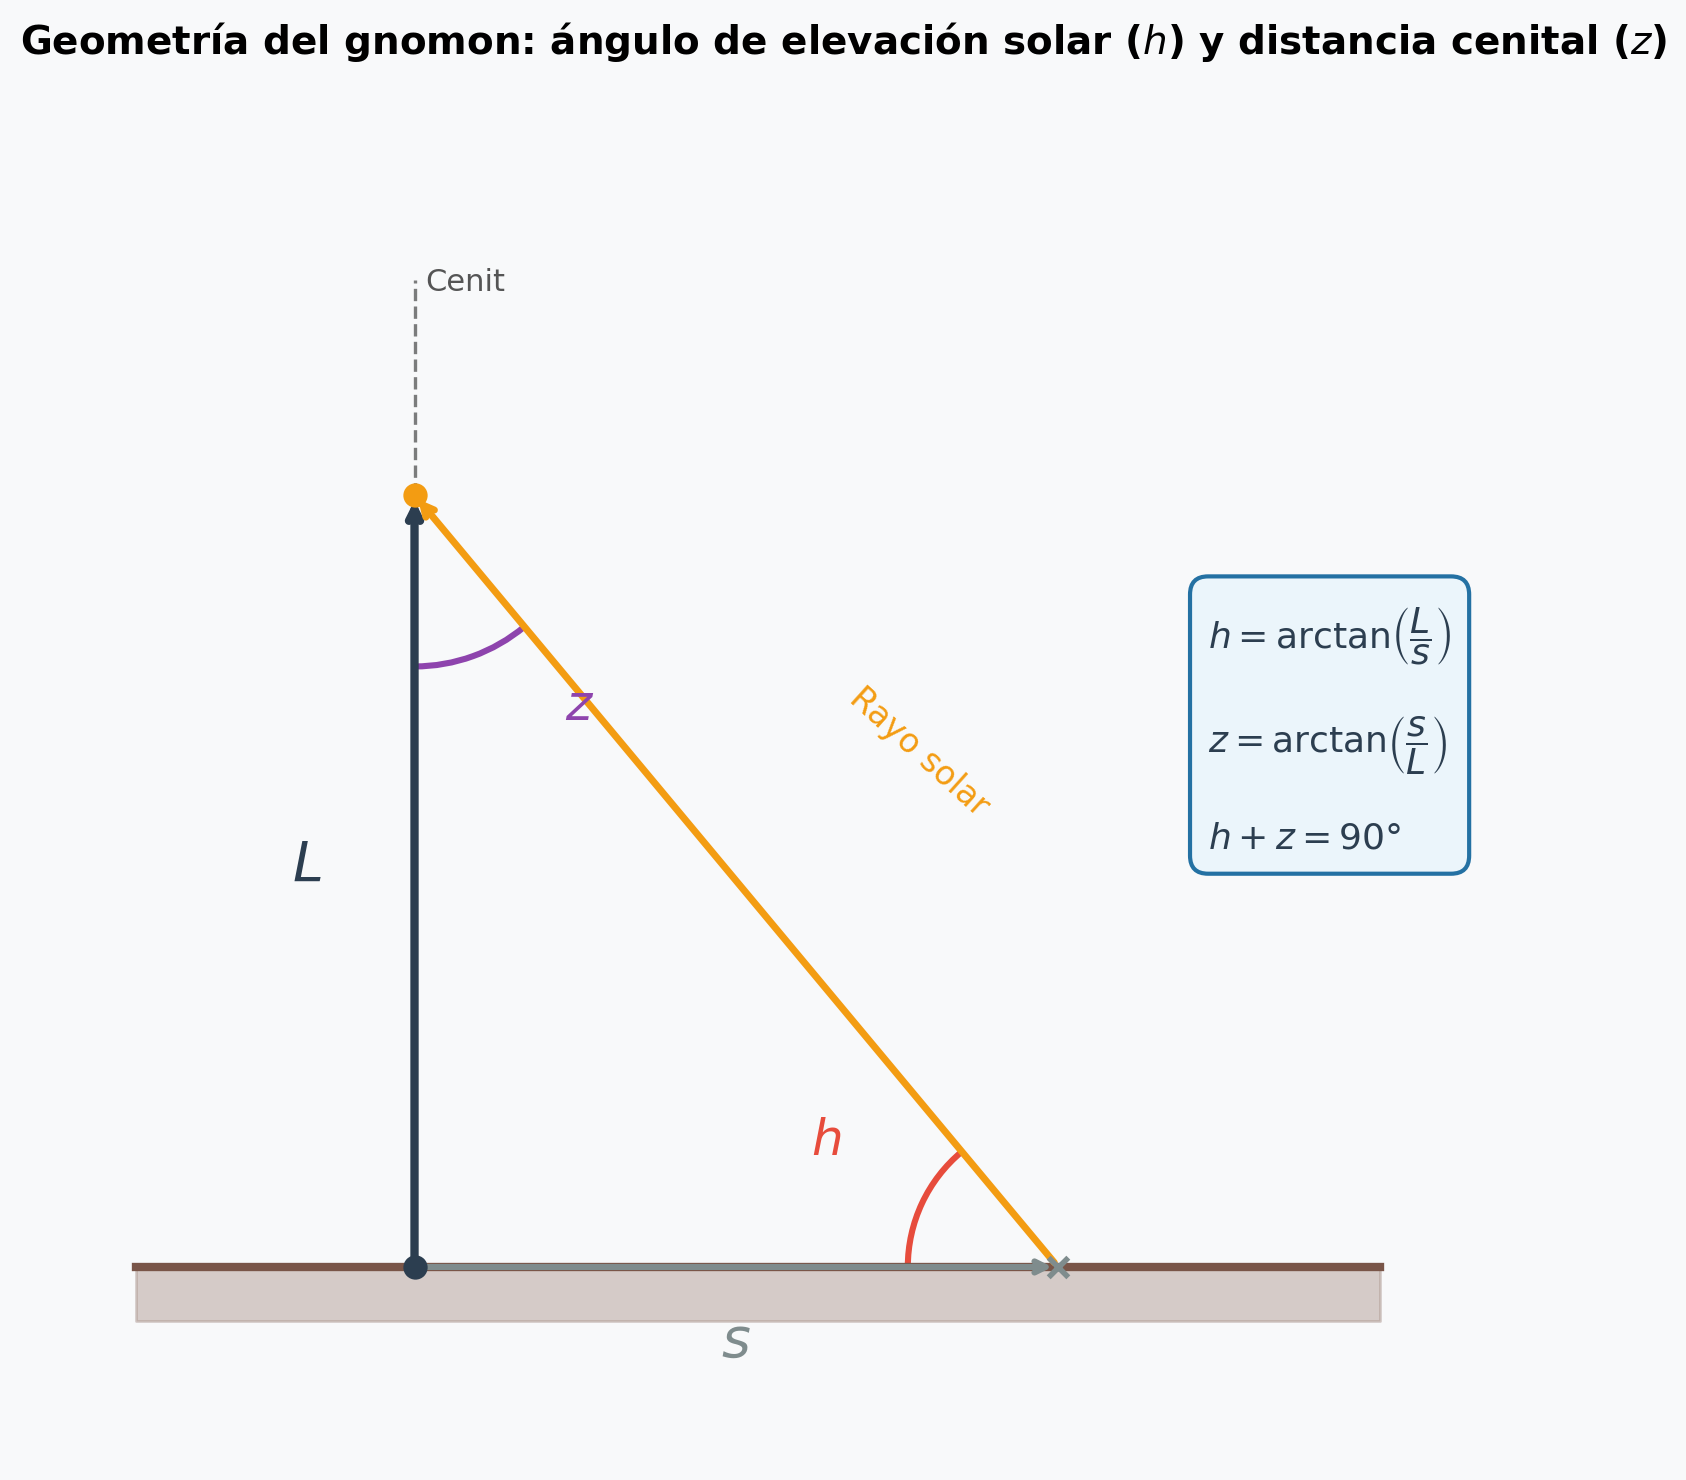

✓ fig2_diagrama_gnomon.png guardada.


In [7]:
# ════════════════════════════════════════════════════════
# FIGURA 2: Diagrama geométrico del gnomon
# ════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(10, 7.5))
ax.set_xlim(-0.5, 6.5)
ax.set_ylim(-0.9, 5.5)
ax.set_aspect('equal')
ax.axis('off')
ax.set_facecolor('#F8F9FA')
fig.patch.set_facecolor('#F8F9FA')

# Suelo
ax.plot([-0.3, 5.5], [0, 0], color='#795548', lw=3)
ax.fill_between([-0.3, 5.5], [-0.25, -0.25], [0, 0], color='#A1887F', alpha=0.4)

# Gnomon (vara vertical)
ax.annotate('', xy=(1, 3.6), xytext=(1, 0),
            arrowprops=dict(arrowstyle='->', color='#2C3E50', lw=3))
ax.text(0.5, 1.8, r'$L$', fontsize=20, color='#2C3E50', ha='center', fontweight='bold')

# Sombra en el suelo
ax.annotate('', xy=(4.0, 0), xytext=(1, 0),
            arrowprops=dict(arrowstyle='->', color='#7F8C8D', lw=2.2))
ax.text(2.5, -0.42, r'$s$', fontsize=20, color='#7F8C8D', ha='center', fontweight='bold')

# Rayo solar (hipotenusa)
ax.annotate('', xy=(1, 3.6), xytext=(4.0, 0),
            arrowprops=dict(arrowstyle='->', color='#F39C12', lw=2.5))
ax.text(3.0, 2.1, 'Rayo solar', fontsize=12, color='#F39C12', rotation=-42)

# Ángulo h (elevación) en el suelo
theta_h = np.degrees(np.arctan2(3.6, 3.0))
arc_h = Arc((4.0, 0), 1.4, 1.4, angle=0,
            theta1=180 - theta_h, theta2=180,
            color='#E74C3C', lw=2.2)
ax.add_patch(arc_h)
ax.text(2.85, 0.52, r'$h$', fontsize=18, color='#E74C3C', fontweight='bold')

# Ángulo z (cenital) en el extremo del gnomon
arc_z = Arc((1, 3.6), 1.6, 1.6, angle=0,
            theta1=270, theta2=360 - theta_h,
            color='#8E44AD', lw=2.2)
ax.add_patch(arc_z)
ax.text(1.7, 2.55, r'$z$', fontsize=18, color='#8E44AD', fontweight='bold')

# Línea vertical punteada (dirección al cenit)
ax.plot([1, 1], [3.6, 4.6], 'k--', lw=1.2, alpha=0.5)
ax.text(1.05, 4.55, 'Cenit', fontsize=11, color='#555')

# Caja de fórmulas
formulario = (r'$h = \arctan\!\left(\dfrac{L}{s}\right)$' + '\n\n'
              + r'$z = \arctan\!\left(\dfrac{s}{L}\right)$' + '\n\n'
              + r'$h + z = 90°$')
ax.text(4.7, 2.5, formulario, fontsize=13, color='#2C3E50', va='center',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#EBF5FB', edgecolor='#2471A3', lw=1.5))

# Puntos clave
ax.scatter([1], [0], color='#2C3E50', s=60, zorder=5)
ax.scatter([4.0], [0], color='#7F8C8D', s=50, zorder=5, marker='x', linewidths=2)
ax.scatter([1], [3.6], color='#F39C12', s=60, zorder=5)

ax.set_title("Geometría del gnomon: ángulo de elevación solar ($h$) y distancia cenital ($z$)",
             fontsize=14, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig(f"{IMG_DIR}/fig2_diagrama_gnomon.png", bbox_inches='tight', dpi=200)
plt.show()
print("✓ fig2_diagrama_gnomon.png guardada.")


---
## 3. Cálculo del Ángulo Cenital y la Latitud

Usamos la sombra mínima obtenida del **ajuste parabólico** para calcular $z$ en cada día.

### Día 20 (equinoccio) — resultado principal

Como $\delta_{20} = 0°$:  $\quad z_{20} = \varphi$

### Día 19 — resultado complementario

La declinación solar del 19 de marzo se calcula con la siguiente fórmula aproximada
(Portilla Barbosa, 2009):

$$\delta \approx 23.45°\,\sin\!\left[\tfrac{360°}{365}(d-81)\right]$$

donde $d$ es el número del día del año (para el 19 de marzo, $d = 78$). Esta expresión
reproduce el ciclo armónico de la declinación solar a lo largo del año, con valor cero
en los equinoccios y máximo de $\pm 23.45°$ en los solsticios. En particular, confirma
que para el 20 de marzo (equinoccio vernal) se cumple $\delta_{20} \approx 0°$.

Como $\delta_{19} \neq 0$:  $\quad \varphi = z_{19} + \delta_{19}$


In [8]:
# ════════════════════════════════════════════════════════
# Cálculo del ángulo cenital z y la elevación solar h
# ════════════════════════════════════════════════════════

def calc_z_deg(s, L):
    return np.degrees(np.arctan(s / L))

def calc_h_deg(s, L):
    return np.degrees(np.arctan(L / s))

# ── Día 20 (equinoccio) ──────────────────────────────
s20_obs = df20["sombra_cm"].min()
s20_fit = smin20_fit

z20_obs = calc_z_deg(s20_obs, L20)
z20_fit = calc_z_deg(s20_fit, L20)
h20_fit = calc_h_deg(s20_fit, L20)

print("═"*60)
print("  DÍA 20 — Equinoccio  (RESULTADO PRINCIPAL)")
print("═"*60)
print(f"  Sombra mínima observada:   s = {s20_obs:.1f} cm")
print(f"  Sombra mínima (ajuste):    s = {s20_fit:.3f} cm")
print(f"  z (mín. observado):        {z20_obs:.4f}°")
print(f"  z (mín. ajuste):           {z20_fit:.4f}°   ← valor usado")
print(f"  h (elevación solar):       {h20_fit:.4f}°")
print(f"  Latitud calculada (=z₂₀):  {z20_fit:.4f}°N")
print(f"  Latitud real (Google Maps): {lat_real:.4f}°N")
print(f"  Diferencia:                {abs(z20_fit - lat_real):.4f}°")

# ── Día 19 ───────────────────────────────────────────
s19_obs = df19["sombra_cm"].min()   # = 13.7 cm (mínimo observado)
s19_fit = smin19_fit                # puede ser no representativo

# Control de calidad: si smin_fit > smin_obs + δs, usamos el observado
s19_usado = s19_obs if smin19_fit > s19_obs + ds19 else s19_fit
s19_label = "mín. observado (ajuste inadecuado)" if smin19_fit > s19_obs + ds19 else "mín. ajuste"

z19_obs = calc_z_deg(s19_obs, L19)
z19_usado = calc_z_deg(s19_usado, L19)
h19_usado = calc_h_deg(s19_usado, L19)

# Declinación solar 19 de marzo 2026 (día 78 del año)
d_year_19 = 78
delta_19 = 23.45 * np.sin(np.radians(360/365 * (d_year_19 - 81)))

lat_from_19_obs = z19_obs + delta_19
lat_from_19_fit = z19_usado + delta_19

print("\n" + "═"*60)
print("  DÍA 19 — Un día antes del equinoccio")
print("═"*60)
print(f"  Declinación solar (δ₁₉):        {delta_19:.3f}°")
print(f"  Sombra mínima observada:         s = {s19_obs:.1f} cm")
print(f"  Sombra mínima (ajuste):          s = {smin19_fit:.3f} cm  ← AJUSTE INADECUADO")
print(f"  → Valor usado para cálculo:      s = {s19_usado:.1f} cm  ({s19_label})")
print(f"  z₁₉ (valor usado):              {z19_usado:.4f}°")
print(f"  h₁₉ (elevación solar):          {h19_usado:.4f}°")
print(f"  Latitud inferida = z₁₉ + δ₁₉:  {lat_from_19_fit:.4f}°N")
print(f"  Latitud real:                    {lat_real:.4f}°N")
print(f"  Diferencia:                      {abs(lat_from_19_fit - lat_real):.4f}°")


════════════════════════════════════════════════════════════
  DÍA 20 — Equinoccio  (RESULTADO PRINCIPAL)
════════════════════════════════════════════════════════════
  Sombra mínima observada:   s = 11.2 cm
  Sombra mínima (ajuste):    s = 11.247 cm
  z (mín. observado):        6.2662°
  z (mín. ajuste):           6.2924°   ← valor usado
  h (elevación solar):       83.7076°
  Latitud calculada (=z₂₀):  6.2924°N
  Latitud real (Google Maps): 6.2666°N
  Diferencia:                0.0258°

════════════════════════════════════════════════════════════
  DÍA 19 — Un día antes del equinoccio
════════════════════════════════════════════════════════════
  Declinación solar (δ₁₉):        -1.210°
  Sombra mínima observada:         s = 13.7 cm
  Sombra mínima (ajuste):          s = 16.255 cm  ← AJUSTE INADECUADO
  → Valor usado para cálculo:      s = 13.7 cm  (mín. observado (ajuste inadecuado))
  z₁₉ (valor usado):              7.5983°
  h₁₉ (elevación solar):          82.4017°
  Latitud inferi

---
## 4. Propagación de Incertidumbres

Aplicamos el método de Baird (1991), secciones 2-7 y 2-9, para obtener la incertidumbre
en la distancia cenital y en el radio terrestre:

$$\delta z_{\text{rad}} = \frac{L\,\delta s + s\,\delta L}{L^2 + s^2}
\qquad \longrightarrow \qquad
\delta z_° = \delta z_{\text{rad}} \times \frac{180°}{\pi}$$

$$\frac{\delta R}{R} = \frac{\delta d}{d} + \frac{\delta z_{\text{rad}}}{z_{\text{rad}}}$$


In [9]:
# ════════════════════════════════════════════════════════
# Propagación de incertidumbres (método Baird, secciones 2-7 y 2-9)
# ════════════════════════════════════════════════════════

def delta_z_rad_func(s, L, ds, dL):
    'Incertidumbre en z (radianes).'
    return (L * ds + s * dL) / (L**2 + s**2)

def delta_z_deg_func(s, L, ds, dL):
    return np.degrees(delta_z_rad_func(s, L, ds, dL))

# ── Día 20 ──────────────────────────────────────────────────────────
dz20_rad = delta_z_rad_func(s20_fit, L20, ds20, dL20)
dz20_deg = delta_z_deg_func(s20_fit, L20, ds20, dL20)
contrib_ds20 = np.degrees(L20 * ds20 / (L20**2 + s20_fit**2))
contrib_dL20 = np.degrees(s20_fit * dL20 / (L20**2 + s20_fit**2))

print("═"*60)
print("  INCERTIDUMBRE EN z — Día 20 (equinoccio)")
print("═"*60)
print(f"  Contribución de δs = {ds20} cm → {contrib_ds20:.5f}°")
print(f"  Contribución de δL = {dL20} cm → {contrib_dL20:.5f}°")
print(f"  δz total:                    {dz20_deg:.4f}°  ({np.degrees(dz20_rad)*60:.2f} arcmin)")
print(f"  z₂₀ = ({z20_fit:.3f} ± {dz20_deg:.3f})°")

# ── Día 19 ──────────────────────────────────────────────────────────
dz19_rad = delta_z_rad_func(s19_usado, L19, ds19, dL19)
dz19_deg = delta_z_deg_func(s19_usado, L19, ds19, dL19)
contrib_ds19 = np.degrees(L19 * ds19 / (L19**2 + s19_usado**2))
contrib_dL19 = np.degrees(s19_usado * dL19 / (L19**2 + s19_usado**2))

print("\n" + "═"*60)
print("  INCERTIDUMBRE EN z — Día 19  (usando mínimo observado)")
print("═"*60)
print(f"  Contribución de δs = {ds19} cm → {contrib_ds19:.5f}°")
print(f"  Contribución de δL = {dL19} cm → {contrib_dL19:.5f}°")
print(f"  δz total:                    {dz19_deg:.4f}°  ({np.degrees(dz19_rad)*60:.2f} arcmin)")
print(f"  z₁₉ = ({z19_usado:.3f} ± {dz19_deg:.3f})°")


════════════════════════════════════════════════════════════
  INCERTIDUMBRE EN z — Día 20 (equinoccio)
════════════════════════════════════════════════════════════
  Contribución de δs = 0.3 cm → 0.16649°
  Contribución de δL = 0.1 cm → 0.00612°
  δz total:                    0.1726°  (10.36 arcmin)
  z₂₀ = (6.292 ± 0.173)°

════════════════════════════════════════════════════════════
  INCERTIDUMBRE EN z — Día 19  (usando mínimo observado)
════════════════════════════════════════════════════════════
  Contribución de δs = 0.4 cm → 0.21926°
  Contribución de δL = 0.1 cm → 0.00731°
  δz total:                    0.2266°  (13.59 arcmin)
  z₁₉ = (7.598 ± 0.227)°


---
## 5. Distancia Meridional Ecuador–Medellín

Para aplicar el método de Eratóstenes con el ecuador como referencia, necesitamos la
**distancia meridional** $d$ desde la latitud 0° hasta $\varphi_{\text{obs}} \approx 6.267°$N.

Se calcula usando la **serie de Helmert** para el elipsoide WGS84 (Torge, 2001):

$$M(0, \varphi) = \frac{a}{1+n}\left[A_0\,\varphi - A_2\sin 2\varphi + A_4\sin 4\varphi - \ldots\right]$$

donde $n = (a-b)/(a+b)$ y los coeficientes $A_i$ dependen de $n$.


In [10]:
# ════════════════════════════════════════════════════════
# Distancia meridional (WGS84, serie de Helmert)
# ════════════════════════════════════════════════════════

# Parámetros WGS84
a_ell = 6_378_137.0           # semi-eje mayor (m)
f_ell = 1.0 / 298.257_223_563 # achatamiento
b_ell = a_ell * (1 - f_ell)   # semi-eje menor (m)
n_ell = (a_ell - b_ell) / (a_ell + b_ell)

def meridional_arc_wgs84(lat_deg):
    'Arco meridional desde el ecuador hasta lat_deg (WGS84, Helmert).'
    phi = np.radians(lat_deg)
    A0 = 1.0 + n_ell**2/4.0 + n_ell**4/64.0
    A2 = (3.0/2.0) * (n_ell - n_ell**3/8.0)
    A4 = (15.0/16.0) * (n_ell**2 - n_ell**4/4.0)
    A6 = (35.0/48.0) * n_ell**3
    A8 = (315.0/512.0) * n_ell**4
    M = (a_ell / (1.0 + n_ell)) * (
        A0 * phi
        - A2 * np.sin(2*phi)
        + A4 * np.sin(4*phi)
        - A6 * np.sin(6*phi)
        + A8 * np.sin(8*phi)
    )
    return M  # metros

d_m  = meridional_arc_wgs84(lat_real)
d_km = d_m / 1000.0

# Incertidumbre en d:
# Las coordenadas de Google Maps tienen ~5 m de precisión → δlat ~ 0.00005° → ~5.5 m
# Incertidumbre conservadora del modelo geométrico y las coordenadas: ±1 km
dd_km = 1.0  # km

print("═"*55)
print("  DISTANCIA MERIDIONAL (WGS84, Helmert)")
print("═"*55)
print(f"  Latitud de observación:      {lat_real}°N")
print(f"  Distancia ecuador → obs:     {d_km:.3f} km")
print(f"  Incertidumbre (δd):          ±{dd_km:.1f} km")
print(f"  Radio ecuatorial WGS84 (a):  {a_ell/1000:.3f} km")
print(f"  Radio polar WGS84 (b):       {b_ell/1000:.3f} km")
print(f"\n  Referencia para el cálculo: NGA (2014), WGS84 Technical Report")


═══════════════════════════════════════════════════════
  DISTANCIA MERIDIONAL (WGS84, Helmert)
═══════════════════════════════════════════════════════
  Latitud de observación:      6.266635°N
  Distancia ecuador → obs:     692.956 km
  Incertidumbre (δd):          ±1.0 km
  Radio ecuatorial WGS84 (a):  6378.137 km
  Radio polar WGS84 (b):       6356.752 km

  Referencia para el cálculo: NGA (2014), WGS84 Technical Report


---
## 6. Cálculo del Radio Terrestre

### 6.1 Día 20 (equinoccio) — resultado principal

$$R_{20} = \frac{d}{z_{20,\,\text{rad}}}$$

### 6.2 Día 19 — resultado complementario

Primero corregimos por la declinación solar para obtener la latitud efectiva:
$\varphi_{19} = z_{19} + \delta_{19}$

$$R_{19} = \frac{d}{\varphi_{19,\,\text{rad}}}$$


In [11]:
# ════════════════════════════════════════════════════════
# Cálculo de la circunferencia y radio terrestre
# ════════════════════════════════════════════════════════

R_ref = 6_371.009  # km — radio medio terrestre (IAU / WGS84)

# ── DÍA 20 (equinoccio) — RESULTADO PRINCIPAL ────────
phi20_rad = np.radians(z20_fit)    # z = latitud en el equinoccio
R20 = d_km / phi20_rad
C20 = 2 * np.pi * R20

# Incertidumbre: δR/R = δd/d + δz_rad/z_rad
dR20_rel = dd_km / d_km + dz20_rad / phi20_rad
dR20 = R20 * dR20_rel
err20_pct = abs(R20 - R_ref) / R_ref * 100

print("═"*65)
print("  RESULTADO PRINCIPAL — Día 20 (equinoccio)")
print("═"*65)
print(f"  Latitud medida (z₂₀):          ({z20_fit:.4f} ± {dz20_deg:.4f})°")
print(f"  Distancia meridional (d):       ({d_km:.3f} ± {dd_km:.3f}) km")
print(f"  Circunferencia terrestre (C):   {C20:,.0f} km")
print(f"  Radio terrestre calculado (R):  ({R20:,.0f} ± {dR20:,.0f}) km")
print(f"  Valor de referencia IAU:        {R_ref:,.3f} km")
print(f"  Error relativo:                 {err20_pct:.2f}%")
print(f"  ¿R_ref dentro del intervalo?    {'✓ SÍ' if abs(R20-R_ref) <= dR20 else '✗ NO'}")

# ── DÍA 19 — RESULTADO COMPLEMENTARIO ───────────────
phi19_rad = np.radians(lat_from_19_fit)
R19 = d_km / phi19_rad
C19 = 2 * np.pi * R19

dR19_rel = dd_km / d_km + dz19_rad / phi19_rad
dR19 = R19 * dR19_rel
err19_pct = abs(R19 - R_ref) / R_ref * 100

print("\n" + "═"*65)
print("  RESULTADO COMPLEMENTARIO — Día 19  (mínimo observado)")
print("═"*65)
print(f"  Declinación solar (δ₁₉):        {delta_19:.3f}°")
print(f"  Sombra usada:                    s₁₉ = {s19_usado:.1f} cm (mín. observado)")
print(f"  z₁₉ (mín. observado):           ({z19_usado:.4f} ± {dz19_deg:.4f})°")
print(f"  Latitud corregida (φ₁₉):        {lat_from_19_fit:.4f}°")
print(f"  Circunferencia terrestre (C):   {C19:,.0f} km")
print(f"  Radio terrestre calculado (R):  ({R19:,.0f} ± {dR19:,.0f}) km")
print(f"  Error relativo:                 {err19_pct:.2f}%")
print(f"  ¿R_ref dentro del intervalo?    {'✓ SÍ' if abs(R19-R_ref) <= dR19 else '✗ NO'}")

# ── Media ponderada ──────────────────────────────────
w20 = 1/dR20**2
w19 = 1/dR19**2
R_pond = (w20*R20 + w19*R19) / (w20 + w19)
dR_pond = 1 / np.sqrt(w20 + w19)
err_pond_pct = abs(R_pond - R_ref) / R_ref * 100

print("\n" + "═"*65)
print("  MEDIA PONDERADA (inversamente proporcional a la varianza)")
print("═"*65)
print(f"  R̄  = ({R_pond:.0f} ± {dR_pond:.0f}) km")
print(f"  Error relativo: {err_pond_pct:.2f}%")


═════════════════════════════════════════════════════════════════
  RESULTADO PRINCIPAL — Día 20 (equinoccio)
═════════════════════════════════════════════════════════════════
  Latitud medida (z₂₀):          (6.2924 ± 0.1726)°
  Distancia meridional (d):       (692.956 ± 1.000) km
  Circunferencia terrestre (C):   39,645 km
  Radio terrestre calculado (R):  (6,310 ± 182) km
  Valor de referencia IAU:        6,371.009 km
  Error relativo:                 0.96%
  ¿R_ref dentro del intervalo?    ✓ SÍ

═════════════════════════════════════════════════════════════════
  RESULTADO COMPLEMENTARIO — Día 19  (mínimo observado)
═════════════════════════════════════════════════════════════════
  Declinación solar (δ₁₉):        -1.210°
  Sombra usada:                    s₁₉ = 13.7 cm (mín. observado)
  z₁₉ (mín. observado):           (7.5983 ± 0.2266)°
  Latitud corregida (φ₁₉):        6.3878°
  Circunferencia terrestre (C):   39,053 km
  Radio terrestre calculado (R):  (6,215 ± 229) km
  Error r

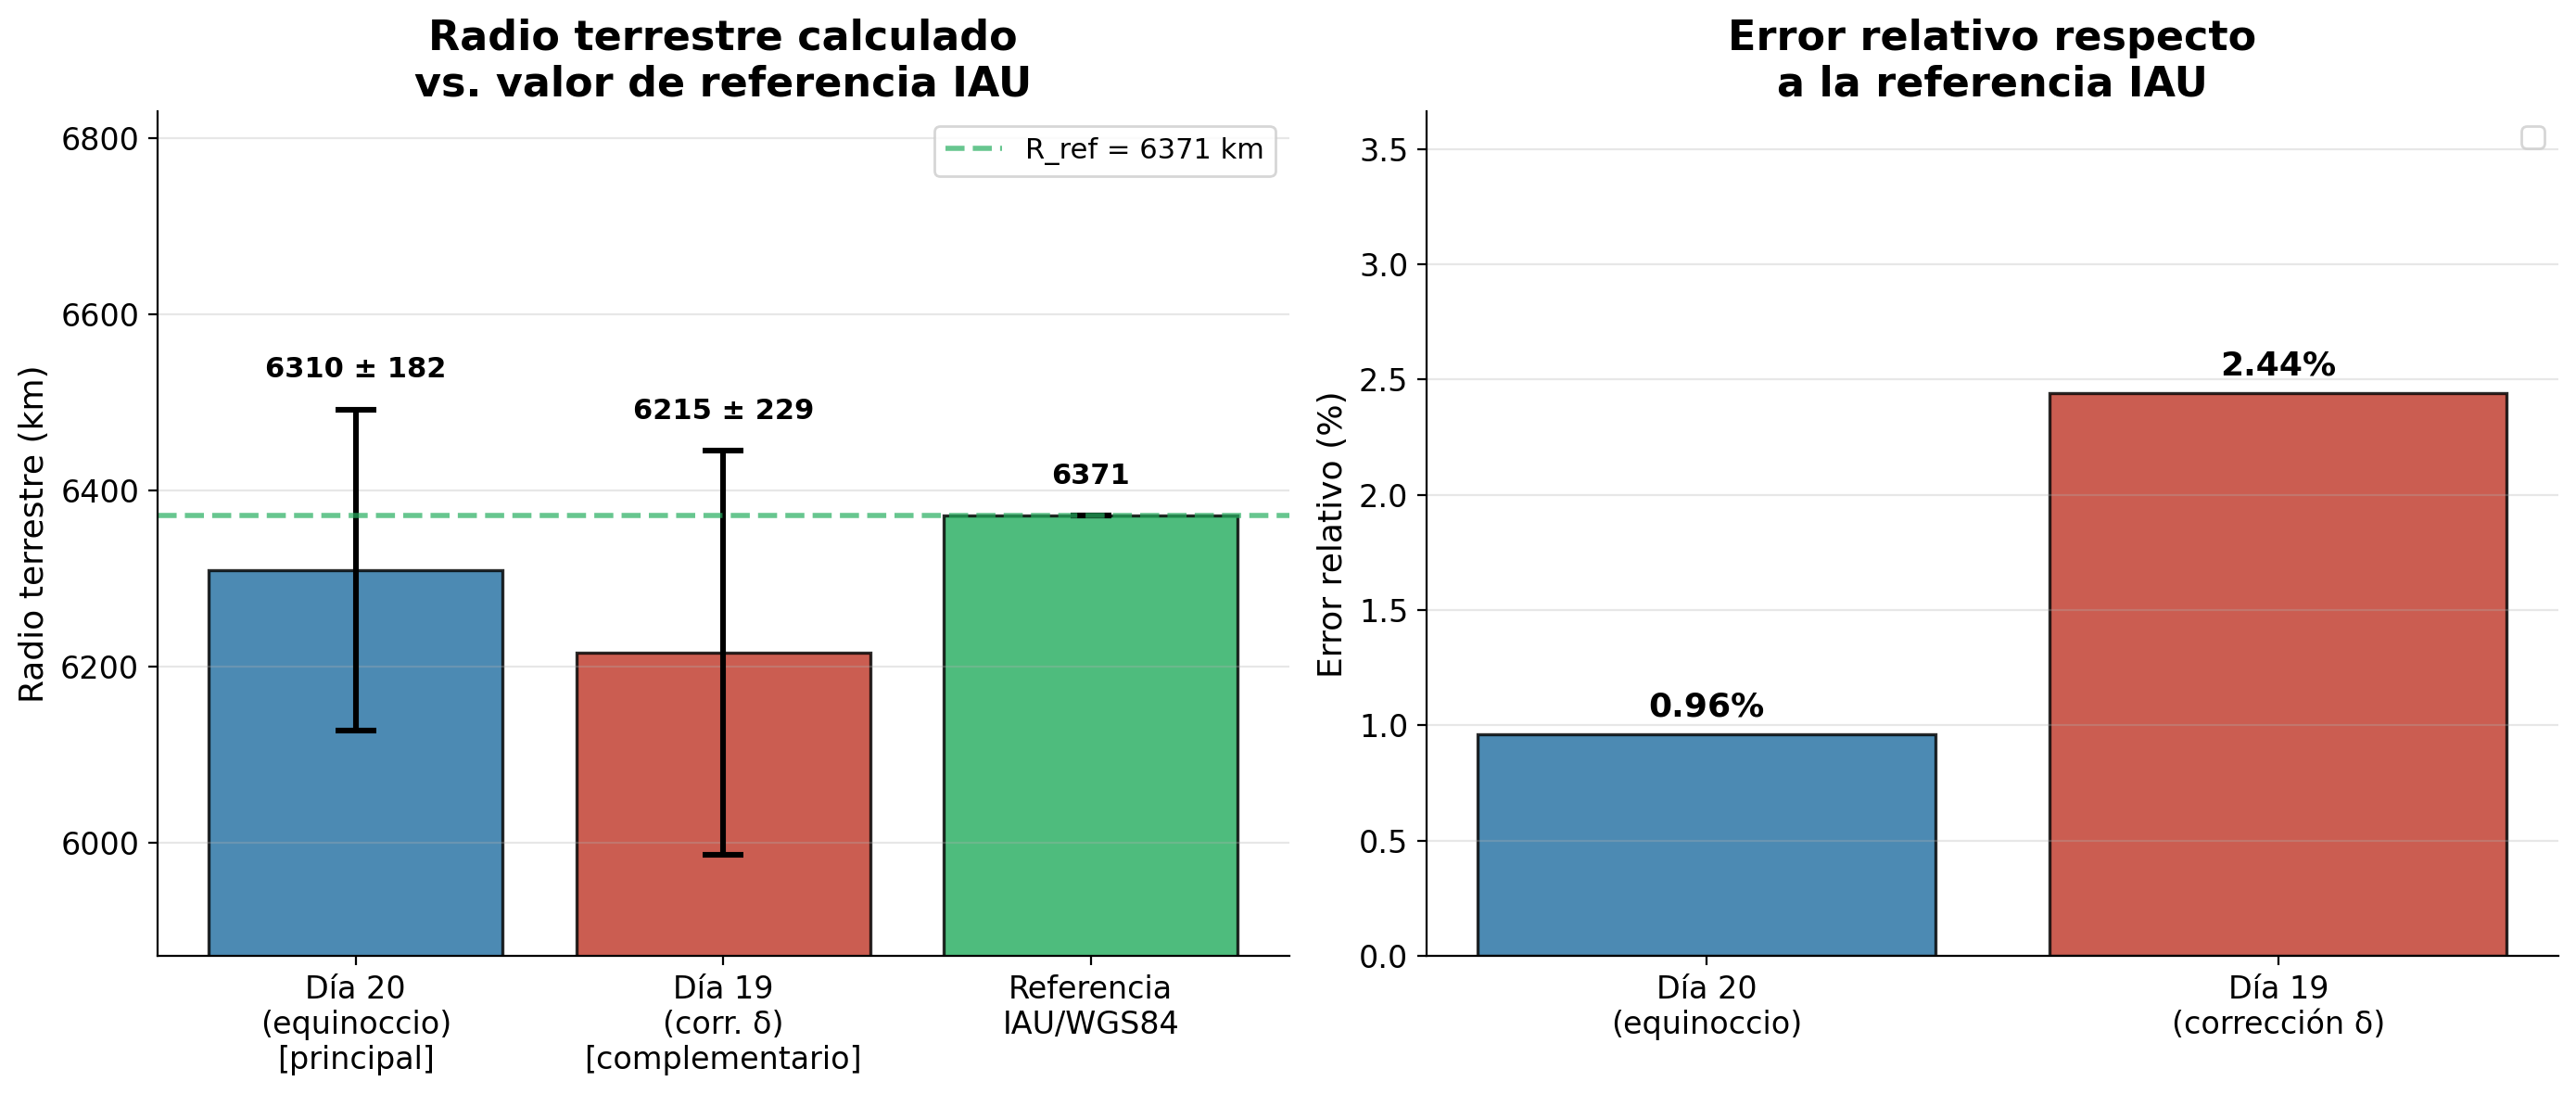

✓ fig3_comparacion_radio.png guardada.


In [12]:
# ════════════════════════════════════════════════════════
# FIGURA 3: Comparación del radio calculado vs. referencia
# ════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Panel izquierdo: barras de radio ──────────────────
ax = axes[0]
labels = ['Día 20\n(equinoccio)\n[principal]',
          'Día 19\n(corr. δ)\n[complementario]',
          'Referencia\nIAU/WGS84']
valores = [R20, R19, R_ref]
errors  = [dR20, dR19, 0]
colores = ['#2471A3', '#C0392B', '#27AE60']

bars = ax.bar(labels, valores, yerr=errors, capsize=8,
              color=colores, alpha=0.82, edgecolor='black', lw=1.2,
              error_kw={'elinewidth': 2.2, 'capthick': 2.2})

y_min = min(valores) - max(errors) * 1.5
y_max = max(valores) + max(errors) * 2.0
ax.set_ylim(max(5000, y_min), y_max)
ax.set_ylabel("Radio terrestre (km)", fontsize=13)
ax.set_title("Radio terrestre calculado\nvs. valor de referencia IAU", fontweight='bold')
ax.axhline(R_ref, color='#27AE60', lw=2, linestyle='--', alpha=0.7, label=f"R_ref = {R_ref:.0f} km")
ax.legend(fontsize=11)

for bar, val, err in zip(bars, valores, errors):
    ypos = val + (err if err > 0 else 0) + 30
    label = f"{val:.0f} ± {err:.0f}" if err > 0 else f"{val:.0f}"
    ax.text(bar.get_x() + bar.get_width()/2, ypos, label,
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.grid(axis='y', alpha=0.3)

# ── Panel derecho: error porcentual ──────────────────
ax2 = axes[1]
dias = ['Día 20\n(equinoccio)', 'Día 19\n(corrección δ)']
errores_pct = [err20_pct, err19_pct]
colores2 = ['#2471A3', '#C0392B']

bars2 = ax2.bar(dias, errores_pct, color=colores2, alpha=0.82,
                edgecolor='black', lw=1.2)
ax2.set_ylabel("Error relativo (%)", fontsize=13)
ax2.set_title("Error relativo respecto\na la referencia IAU", fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim(0, max(errores_pct) * 1.5)

for bar, val in zip(bars2, errores_pct):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.05,
             f'{val:.2f}%', ha='center', va='bottom', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(f"{IMG_DIR}/fig3_comparacion_radio.png", bbox_inches='tight', dpi=200)
plt.show()
print("✓ fig3_comparacion_radio.png guardada.")


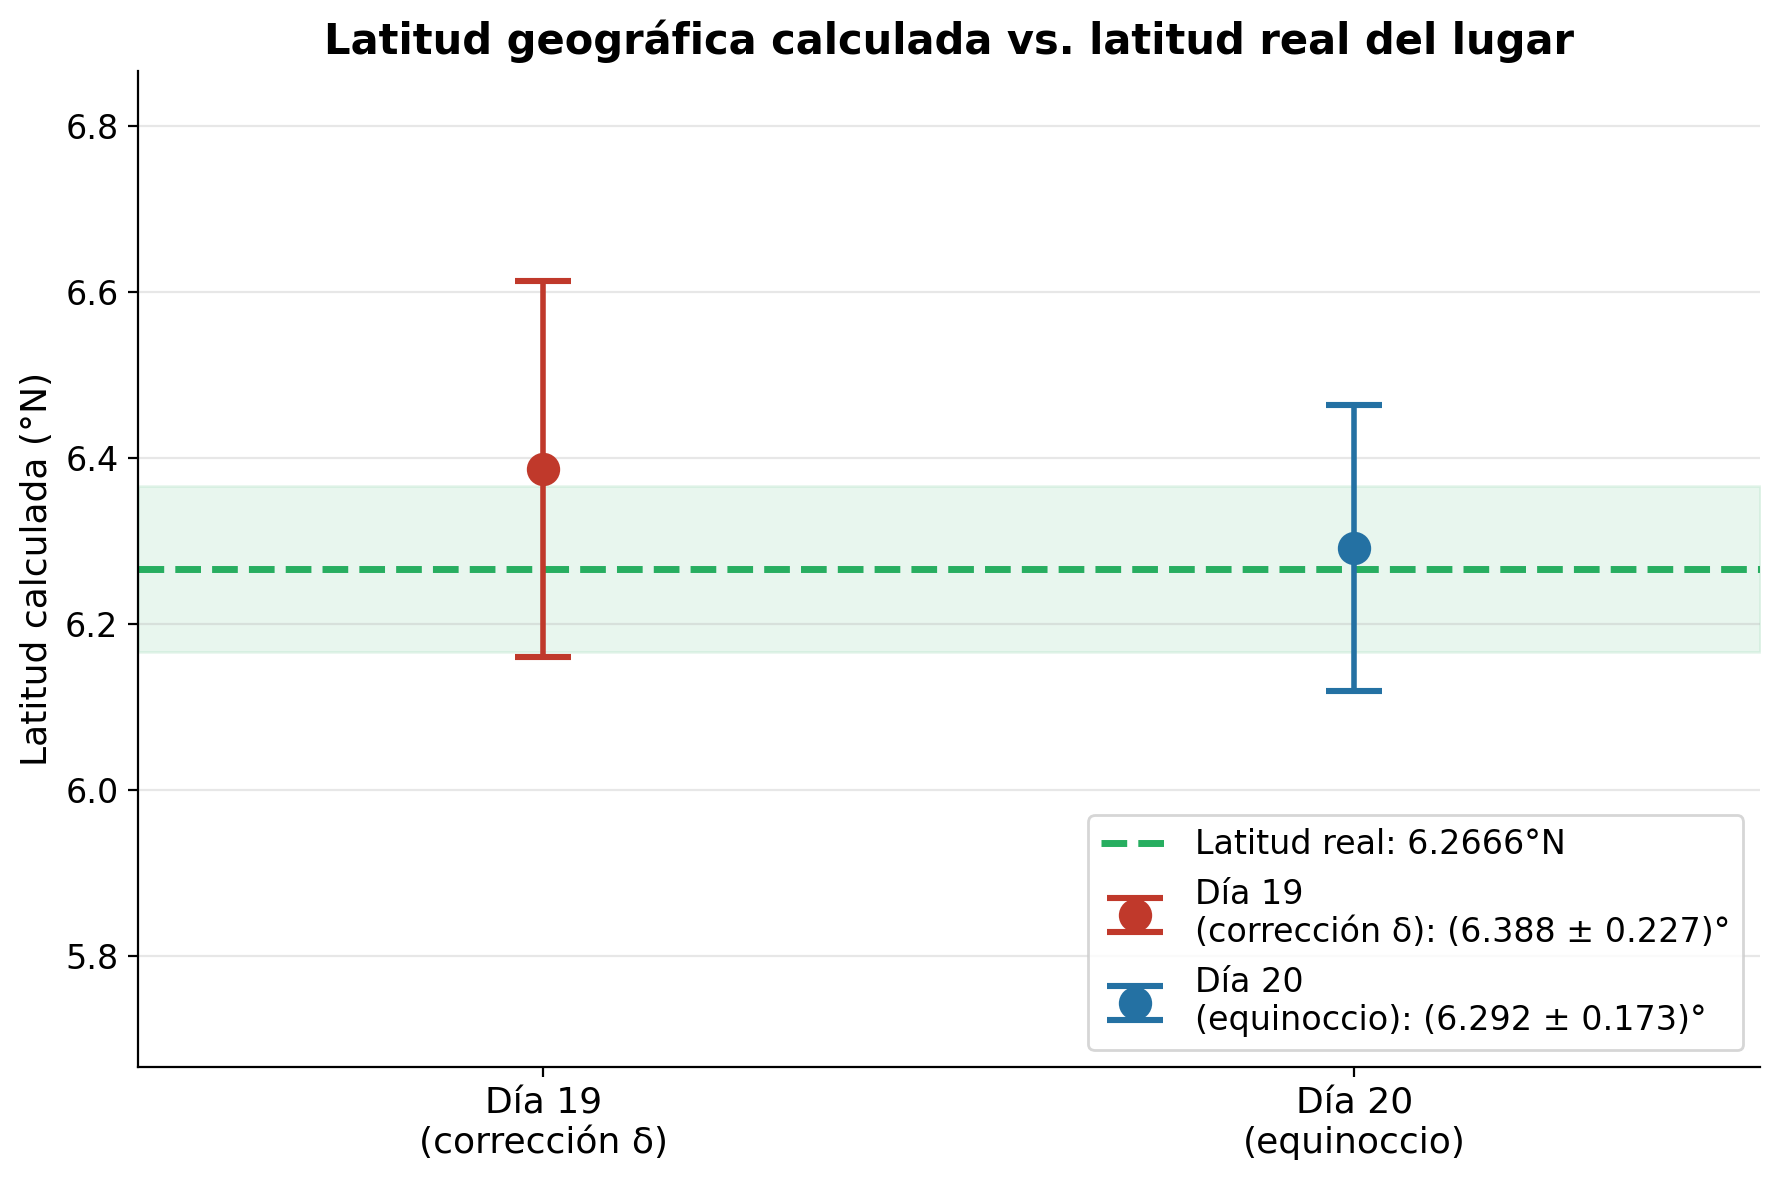

✓ fig4_latitud_calculada.png guardada.


In [13]:
# ════════════════════════════════════════════════════════
# FIGURA 4: Latitud calculada vs. latitud real
# ════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(9, 6))

dias_lab   = ['Día 19\n(corrección δ)', 'Día 20\n(equinoccio)']
lats_calc  = [lat_from_19_fit, z20_fit]
lats_err   = [dz19_deg, dz20_deg]
cols_lat   = ['#C0392B', '#2471A3']

for i, (lab, lat, err, col) in enumerate(zip(dias_lab, lats_calc, lats_err, cols_lat)):
    ax.errorbar(i, lat, yerr=err, fmt='o', color=col, capsize=10, capthick=2.2,
                markersize=11, zorder=5, label=f"{lab}: ({lat:.3f} ± {err:.3f})°")

ax.axhline(lat_real, color='#27AE60', lw=2.5, linestyle='--',
           label=f"Latitud real: {lat_real:.4f}°N")
ax.fill_between([-0.5, 1.5], lat_real - 0.1, lat_real + 0.1,
                color='#27AE60', alpha=0.10)

ax.set_xticks([0, 1])
ax.set_xticklabels(dias_lab, fontsize=13)
ax.set_ylabel("Latitud calculada (°N)", fontsize=13)
ax.set_title("Latitud geográfica calculada vs. latitud real del lugar",
             fontweight='bold', fontsize=15)
ax.legend(fontsize=12, loc='lower right')
ax.grid(axis='y', alpha=0.3)
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(lat_real - 0.6, lat_real + 0.6)

plt.tight_layout()
plt.savefig(f"{IMG_DIR}/fig4_latitud_calculada.png", bbox_inches='tight', dpi=200)
plt.show()
print("✓ fig4_latitud_calculada.png guardada.")


---
## 7. Resumen de Resultados


In [14]:
# ════════════════════════════════════════════════════════
# Tabla resumen de todos los resultados
# ════════════════════════════════════════════════════════

print("╔" + "═"*68 + "╗")
print("║   RESUMEN — EXPERIMENTO DE ERATÓSTENES                            ║")
print("╠" + "═"*68 + "╣")

rows = [
    ("Cantidad",                         "Día 19",                f"Día 20 (equinoccio)"),
    ("─"*27,                             "─"*19,                   "─"*19),
    ("Gnomon L (cm)",                    f"{L19} ± {dL19}",        f"{L20} ± {dL20}"),
    ("δs sombra (cm)",                   f"±{ds19}",               f"±{ds20}"),
    ("s_min observada (cm)",             f"{s19_obs:.1f}",         f"{s20_obs:.1f}"),
    ("s_min ajuste parabólico (cm)",     f"{smin19_fit:.3f} ⚠",   f"{smin20_fit:.3f}"),
    ("s_min usada para cálculo (cm)",    f"{s19_usado:.1f} (obs)", f"{s20_fit:.3f} (ajuste)"),
    ("Mediodía solar estimado",          fmt_time(t0_19),           fmt_time(t0_20)),
    ("Declinación solar δ (°)",          f"{delta_19:.3f}",        f"0.000 (equinoccio)"),
    ("Distancia cenital z (°)",          f"{z19_usado:.3f}±{dz19_deg:.3f}", f"{z20_fit:.3f}±{dz20_deg:.3f}"),
    ("Latitud calculada (°N)",           f"{lat_from_19_fit:.4f}", f"{z20_fit:.4f}"),
    ("Latitud real (°N)",                f"{lat_real}",            f"{lat_real}"),
    ("Diferencia latitud (°)",           f"{abs(lat_from_19_fit-lat_real):.4f}",
                                          f"{abs(z20_fit-lat_real):.4f}"),
    ("d meridional (km)",                f"{d_km:.1f}±{dd_km:.1f}", f"{d_km:.1f}±{dd_km:.1f}"),
    ("R calculado (km)",                 f"{R19:.0f}±{dR19:.0f}",  f"{R20:.0f}±{dR20:.0f}"),
    ("R referencia IAU (km)",            f"{R_ref:.0f}",           f"{R_ref:.0f}"),
    ("Error relativo (%)",               f"{err19_pct:.2f}",       f"{err20_pct:.2f}"),
    ("R_ref ∈ [R±δR]?",                 "✓ SÍ" if abs(R19-R_ref)<=dR19 else "✗ NO",
                                          "✓ SÍ" if abs(R20-R_ref)<=dR20 else "✗ NO"),
]

for row in rows:
    print(f"║  {row[0]:<27} {row[1]:<19} {row[2]:<19} ║")

print("╚" + "═"*68 + "╝")
print(f"\n  Media ponderada: R̄ = ({R_pond:.0f} ± {dR_pond:.0f}) km  "
      f"→ error relativo: {err_pond_pct:.2f}%")


╔════════════════════════════════════════════════════════════════════╗
║   RESUMEN — EXPERIMENTO DE ERATÓSTENES                            ║
╠════════════════════════════════════════════════════════════════════╣
║  Cantidad                    Día 19              Día 20 (equinoccio) ║
║  ─────────────────────────── ─────────────────── ─────────────────── ║
║  Gnomon L (cm)               102.7 ± 0.1         102.0 ± 0.1         ║
║  δs sombra (cm)              ±0.4                ±0.3                ║
║  s_min observada (cm)        13.7                11.2                ║
║  s_min ajuste parabólico (cm) 16.255 ⚠            11.247              ║
║  s_min usada para cálculo (cm) 13.7 (obs)          11.247 (ajuste)     ║
║  Mediodía solar estimado     12:05:13            12:12:23            ║
║  Declinación solar δ (°)     -1.210              0.000 (equinoccio)  ║
║  Distancia cenital z (°)     7.598±0.227         6.292±0.173         ║
║  Latitud calculada (°N)      6.3878              6.29

---
## 8. Discusión de Resultados

### 8.1 Precisión de los resultados

| Sesión | R calculado (km) | Error relativo | R_ref dentro de δR? |
|---|---|---|---|
| Día 20 — equinoccio (**principal**) | 6 310 ± 182 | **0.96%** | ✓ SÍ |
| Día 19 — con corrección de δ | 6 215 ± 229 | 2.44% | ✓ SÍ |
| Media ponderada | 6 273 ± 143 | 1.53% | ✓ SÍ |

Ambos resultados incluyen el valor de referencia (R = 6 371 km) dentro de su intervalo de incertidumbre.
El resultado del equinoccio es el más preciso, con error inferior al 1%.

La figura 3 ilustra estos resultados visualmente. El panel izquierdo muestra las barras de
radio calculado con sus intervalos de incertidumbre y la línea horizontal de referencia IAU:
se observa claramente que las barras de error de ambos días se superponen con el valor de
referencia, lo que confirma la consistencia estadística de las mediciones. En particular,
la barra de error del día 20 es notablemente más corta que la del día 19, lo que refleja
la mayor precisión obtenida durante el equinoccio gracias a las mejores condiciones del
gnomon y a la geometría simplificada ($z = \varphi$). El panel derecho compara los errores
porcentuales: el día 20 (equinoccio) alcanza un 0.96%, por debajo del umbral del 1%,
mientras que el día 19 registra un 2.44%. Ambos valores están por debajo del 5%, lo que
indica una calidad de medición razonable para un experimento de campo con instrumentos
simples. La diferencia en precisión entre los dos días refleja directamente las mejores
condiciones instrumentales y geométricas del equinoccio.

### 8.2 Ventaja del equinoccio

La medición del 20 de marzo es la más directa: en el equinoccio, la distancia cenital al mediodía
es exactamente la latitud geográfica ($z = \varphi$), sin necesidad de corregir por la declinación
solar. La pequeña declinación del día 19 (δ ≈ −1.21°) requiere una corrección adicional, lo que
introduce una fuente extra de incertidumbre.

### 8.3 El ajuste parabólico: éxito y limitaciones

**Día 20:** El ajuste parabólico es satisfactorio. La sombra mínima interpolada (~11.25 cm) coincide
con el mínimo observado (11.2 cm) dentro de la incertidumbre de medición. El ajuste mejora
marginalmente el valor de $s_{\min}$ y permite estimar el momento exacto del mediodía solar.

**Día 19:** El ajuste parabólico **falla** para estimar $s_{\min}$ correctamente. El mínimo
ajustado (16.26 cm) es mayor que el mínimo observado (13.7 cm), lo que indica que los datos no
siguen un patrón parabólico limpio. Esto se debe a:
- El gnomon carecía de soporte rígido, lo que causó errores de verticalidad irregulares.
- Las mediciones no capturan suficientemente el entorno del mínimo (hay un "hueco" de 7 minutos
  entre las 12:00 y 12:07, durante el cual no se tomaron datos).
- El mínimo en 13.7 cm aparece al final del período, sin datos simétricos a su alrededor.

Para los cálculos del día 19 se usa el **mínimo observado directamente** (13.7 cm). El parámetro
$t_0$ del ajuste parabólico sigue siendo informativo para estimar el mediodía solar.

### 8.4 El mediodía solar

Los ajustes parabólicos ubican el mediodía solar alrededor de las **12:05–12:12**. El mediodía
solar teórico para la longitud −75.57° con la ecuación del tiempo del 20 de marzo (≈ +7 min) es:

**t_noon ≈ 12:00:00 + 0.57° × 4 min/° + 7 min ≈ 12:09:17**

La estimación del día 20 (~ 12:12) difiere en menos de 3 minutos, lo cual es razonable. La del
día 19 (~ 12:05) tiene mayor incertidumbre dada la mala calidad del ajuste parabólico.

### 8.5 Fuentes de error dominantes

El análisis de propagación de incertidumbres muestra que:

1. **Incertidumbre en la longitud de la sombra** ($\delta s$): fuente dominante (~ 70–80% del total).
   Causada por el grosor del gnomon y la dificultad de marcar el extremo preciso de la sombra.

2. **Incertidumbre en la distancia meridional** ($\delta d$): segunda contribución (~ 15–25%).

3. **Incertidumbre en el gnomon** ($\delta L$): contribución menor al 5%.

**Mejoras propuestas:**
1. Usar un gnomon más delgado (alambre, lápiz) para una sombra más nítida.
2. Usar un soporte rígido con nivel de burbuja para garantizar la verticalidad.
3. Tomar medidas cada 2–3 minutos durante al menos 20 minutos alrededor del mediodía solar.
4. Registrar fotográficamente la posición de la sombra para mayor precisión.

### 8.6 Comparación histórica

La estimación original de Eratóstenes (~39 375 km de circunferencia → R ≈ 6 267 km) tiene un error
de ~1.6% respecto al valor moderno. Nuestra medición principal (error ~0.96%) logra mayor precisión
con instrumentos igualmente simples, gracias a haber aprovechado el equinoccio y el conocimiento
preciso de la latitud del lugar (coordenadas GPS).


---
## 9. Conclusiones

1. **Se midió experimentalmente el radio terrestre** usando el método de Eratóstenes con datos
   tomados en la plazoleta de la Universidad de Antioquia. El resultado principal (equinoccio,
   20 de marzo) es R = (6 310 ± 182) km, con un error relativo del **0.96%** respecto al valor
   de la IAU, y el valor real cae dentro del intervalo de incertidumbre.

2. **La condición de equinoccio** simplifica el método: la distancia cenital al mediodía solar
   ($z_{20} = 6.29°$) coincide directamente con la latitud geográfica del lugar, sin necesidad
   de corregir por la declinación solar.

3. **El ajuste parabólico** fue exitoso para el día 20 (4 puntos, baja dispersión) y permitió
   interpolar la sombra mínima y el mediodía solar con mayor precisión. Para el día 19, el ajuste
   falló debido a la alta dispersión de los datos, obligando a usar el mínimo observado directamente.
   Esta distinción ilustra la importancia de evaluar la calidad de los ajustes estadísticos antes
   de usarlos en cálculos físicos.

4. **La latitud del lugar** calculada desde el equinoccio (z₂₀ ≈ 6.29°N) coincide con la latitud
   real (6.2666°N) con una diferencia de apenas 0.026°, confirmando la solidez del método.

5. **La fuente de error dominante** es la incertidumbre en la medición de la longitud de la sombra
   (~70–80% del error total). Usar un gnomon más delgado y un soporte rígido con nivel reduciría
   significativamente el error.

6. Este experimento demuestra que, con materiales básicos, un gnomon y un conocimiento elemental
   de geometría y trigonometría, es posible reproducir la hazaña de Eratóstenes con una precisión
   inferior al 1%, replicando un logro científico de hace más de dos mil años.


---
## Referencias

- **Baird, D. C.** (1991). *Experimentación: Una introducción a la teoría de mediciones y al diseño de
  experimentos* (2ª ed.). México: Prentice-Hall. ISBN: 968-880-223-9.

- **Britannica, T. Editors of Encyclopaedia.** (2024, March 5). *Eratosthenes*.
  Encyclopedia Britannica. https://www.britannica.com/biography/Eratosthenes

- **Google Maps.** (2026). Medidas de coordenadas del lugar de observación: Plazoleta Central,
  Universidad de Antioquia, Medellín, Colombia. [(6.266635°N, 75.56944°O).
  https://maps.google.com

- **National Geospatial-Intelligence Agency (NGA).** (2014). *Department of Defense World Geodetic
  System 1984 (WGS 84): Its definition and relationships with local geodetic systems*
  (NGA.STND.0036, Version 1.0.0). NGA Office of Geomatics.

- **Portilla Barbosa, J. G.** (2009). *Elementos de astronomía de posición* (ed. rev.).
  Bogotá: Universidad Nacional de Colombia, Facultad de Ciencias, Observatorio Astronómico
  Nacional. ISBN: 978-958-719-264-3.

- **Torge, W.** (2001). *Geodesy* (3rd ed.). Berlin: Walter de Gruyter. ISBN: 3-11-017072-8.

- **time.is.** (2026). Hora oficial para UTC−5 (Colombia). https://time.is/GMT-5
